In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [17]:
# 1. Загрузка данных
# Скачайте train.csv с Kaggle
df = pd.read_csv('train.csv')

In [19]:
# Выбираем ключевые признаки для наглядности
num_features = ['GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
cat_features = ['Neighborhood', 'HouseStyle']
target = 'SalePrice'

X = df[num_features + cat_features]
y = df[target]

In [20]:
# 2. Разделение выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Предобработка данных (Preprocessing Pipeline)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

In [21]:
# 4. Построение Pipeline с моделью Ridge (L2-регуляризация)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

In [22]:
# 5. Подбор гиперпараметров (GridSearchCV)
param_grid = {
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0]
}

search = GridSearchCV(model_pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
search.fit(X_train, y_train)

best_model = search.best_estimator_

In [23]:
# 6. Оценка качества
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Лучший alpha: {search.best_params_['regressor__alpha']}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

Лучший alpha: 1.0
RMSE: 38946.19
MAE:  25067.20
R²:   0.8023


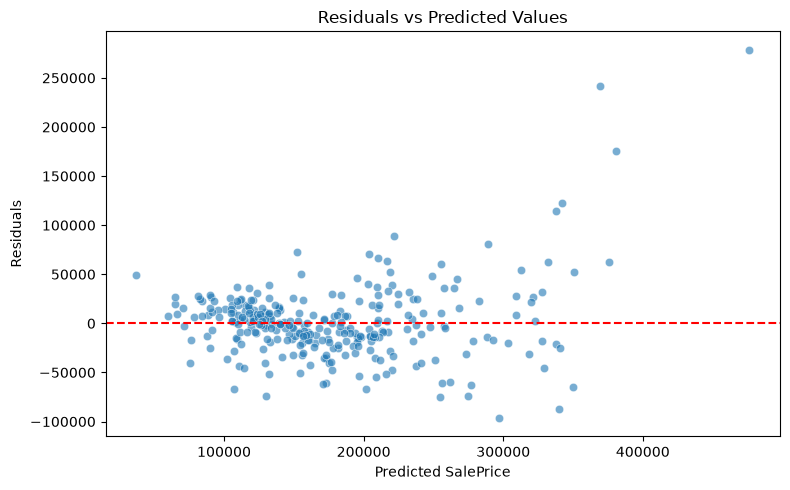

In [26]:
# 7. Анализ остатков (Residual Plot)
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Residuals')
plt.tight_layout()
plt.savefig('residuals_plot.png')
plt.show()